In [1]:
import pandas as pd

# Load the dataset
file_path = "AirPassengers.csv"
df = pd.read_csv(file_path)

# Display the first few rows of the dataset
df.head()


,Month,#Passengers
0,1949-01,112
1,1949-02,118
2,1949-03,132
3,1949-04,129
4,1949-05,121


In [2]:
import numpy as np
from sklearn.preprocessing import MinMaxScaler

# Step 1: Convert 'Month' to datetime and rename columns
df.columns = ['Month', 'Passengers']
df['Month'] = pd.to_datetime(df['Month'])
df.set_index('Month', inplace=True)

# Step 2: Normalize the 'Passengers' column
scaler = MinMaxScaler(feature_range=(0, 1))
scaled_data = scaler.fit_transform(df[['Passengers']])

# Step 3: Create sequences for LSTM
def create_sequences(data, sequence_length):
    X, y = [], []
    for i in range(sequence_length, len(data)):
        X.append(data[i-sequence_length:i, 0])
        y.append(data[i, 0])
    return np.array(X), np.array(y)

sequence_length = 12  # using past 12 months to predict the next
X, y = create_sequences(scaled_data, sequence_length)

# Reshape X to be suitable for LSTM input: [samples, time steps, features]
X = X.reshape((X.shape[0], X.shape[1], 1))

X.shape, y.shape


((132, 12, 1), (132,))

In [3]:
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense

# Step 4: Split into training and testing sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)

# Step 5: Build the LSTM model
model = Sequential([
    LSTM(50, return_sequences=False, input_shape=(X_train.shape[1], 1)),
    Dense(1)
])

model.compile(optimizer='adam', loss='mean_squared_error')

# Step 6: Train the model
history = model.fit(X_train, y_train, epochs=100, batch_size=16, validation_data=(X_test, y_test), verbose=0)

# Return final training and validation loss
history.history['loss'][-1], history.history['val_loss'][-1]


/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


(0.0018571544205769897, 0.01332958322018385)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 176ms/step


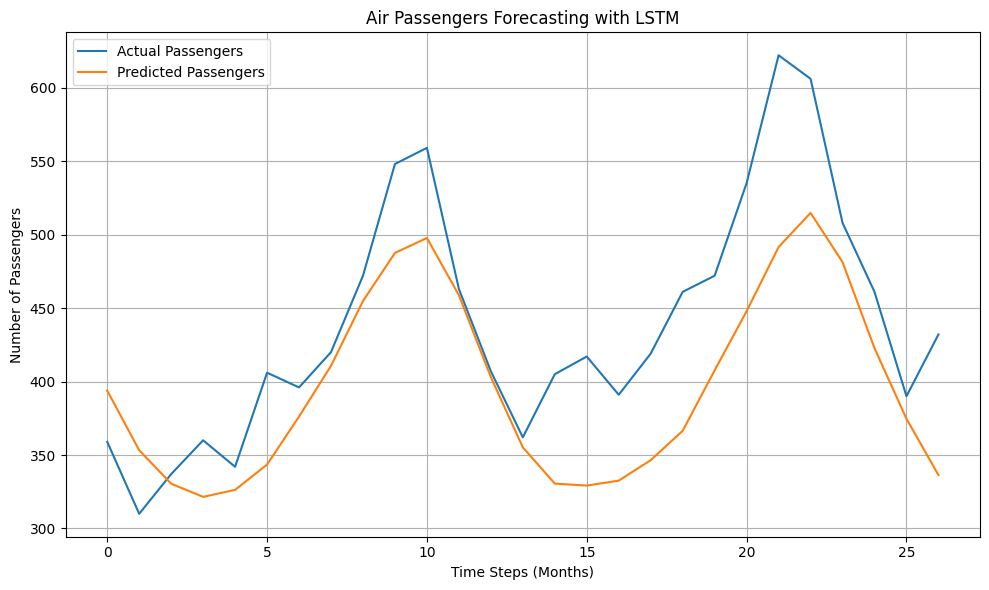

In [4]:
import matplotlib.pyplot as plt

# Step 7: Make predictions
predicted = model.predict(X_test)

# Inverse transform to get actual passenger numbers
predicted_actual_scale = scaler.inverse_transform(predicted.reshape(-1, 1))
y_test_actual_scale = scaler.inverse_transform(y_test.reshape(-1, 1))

# Step 8: Plot actual vs predicted
plt.figure(figsize=(10, 6))
plt.plot(y_test_actual_scale, label='Actual Passengers')
plt.plot(predicted_actual_scale, label='Predicted Passengers')
plt.title('Air Passengers Forecasting with LSTM')
plt.xlabel('Time Steps (Months)')
plt.ylabel('Number of Passengers')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()
